## Модель регрессии

In [2]:
# импортируем библиотеки
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd

### Этап 1. Загрузка данных

**Загрузка данных**. Скачивание датасета из сессионного хранилища

In [4]:
# если код, написанный ранее перестанет работать, просто запустите эту ячейку
# на выходе вы получите уже сформированный датафрейм
boston_df = pd.read_csv('boston.csv')
boston_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [5]:
# посмотрим с каким типом переменных нам предстоит работать
# для этого есть метод .info()
boston_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


In [6]:
# посмотрим на основные статистические показатели (summary statistics)
# с помощью метода .describe()
boston_df.describe().round(2)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00,506.00
mean,3.61,11.36,11.14,0.07,0.55,6.28,68.57,3.80,9.55,408.24,18.46,356.67,12.65,22.53
std,8.60,23.32,6.86,0.25,0.12,0.70,28.15,2.11,8.71,168.54,2.16,91.29,7.14,9.20
min,0.01,0.00,0.46,0.00,0.38,3.56,2.90,1.13,1.00,187.00,12.60,0.32,1.73,5.00
25%,0.08,0.00,5.19,0.00,0.45,5.89,45.02,2.10,4.00,279.00,17.40,375.38,6.95,17.02
50%,0.26,0.00,9.69,0.00,0.54,6.21,77.50,3.21,5.00,330.00,19.05,391.44,11.36,21.20
75%,3.68,12.50,18.10,0.00,0.62,6.62,94.07,5.19,24.00,666.00,20.20,396.22,16.96,25.00
max,88.98,100.00,27.74,1.00,0.87,8.78,100.00,12.13,24.00,711.00,22.00,396.90,37.97,50.00


### Этап 2. Предварительная обработка данных

In [7]:
# проверим, есть ли пропущенные значения
boston_df.isnull().sum()

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

### Этап 3. Исследовательский анализ данных (Exploratory Data Analysis)

In [8]:
# посчитаем коэффициент корреляции для всего датафрейма и округлим значение
# получается корреляционная матрица
corr_matrix = boston_df.corr().round(2)
corr_matrix

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.00,-0.20,0.41,-0.06,0.42,-0.22,0.35,-0.38,0.63,0.58,0.29,-0.39,0.46,-0.39
ZN,-0.20,1.00,-0.53,-0.04,-0.52,0.31,-0.57,0.66,-0.31,-0.31,-0.39,0.18,-0.41,0.36
INDUS,0.41,-0.53,1.00,0.06,0.76,-0.39,0.64,-0.71,0.60,0.72,0.38,-0.36,0.60,-0.48
CHAS,-0.06,-0.04,0.06,1.00,0.09,0.09,0.09,-0.10,-0.01,-0.04,-0.12,0.05,-0.05,0.18
NOX,0.42,-0.52,0.76,0.09,1.00,-0.30,0.73,-0.77,0.61,0.67,0.19,-0.38,0.59,-0.43
RM,-0.22,0.31,-0.39,0.09,-0.30,1.00,-0.24,0.21,-0.21,-0.29,-0.36,0.13,-0.61,0.70
AGE,0.35,-0.57,0.64,0.09,0.73,-0.24,1.00,-0.75,0.46,0.51,0.26,-0.27,0.60,-0.38
DIS,-0.38,0.66,-0.71,-0.10,-0.77,0.21,-0.75,1.00,-0.49,-0.53,-0.23,0.29,-0.50,0.25
RAD,0.63,-0.31,0.60,-0.01,0.61,-0.21,0.46,-0.49,1.00,0.91,0.46,-0.44,0.49,-0.38
TAX,0.58,-0.31,0.72,-0.04,0.67,-0.29,0.51,-0.53,0.91,1.00,0.46,-0.44,0.54,-0.47


In [9]:
# мы также можем построить диаграммы рассеяния, например,
# между целевой переменной MEDV и LSTAT и RM

# подготовим данные (поместим столбцы датафрейма в переменные)
x1 = boston_df['LSTAT']
x2 = boston_df['RM']
y = boston_df['MEDV']

Text(0.5, 1.0, 'Социальный статус населения и цены на жилье')

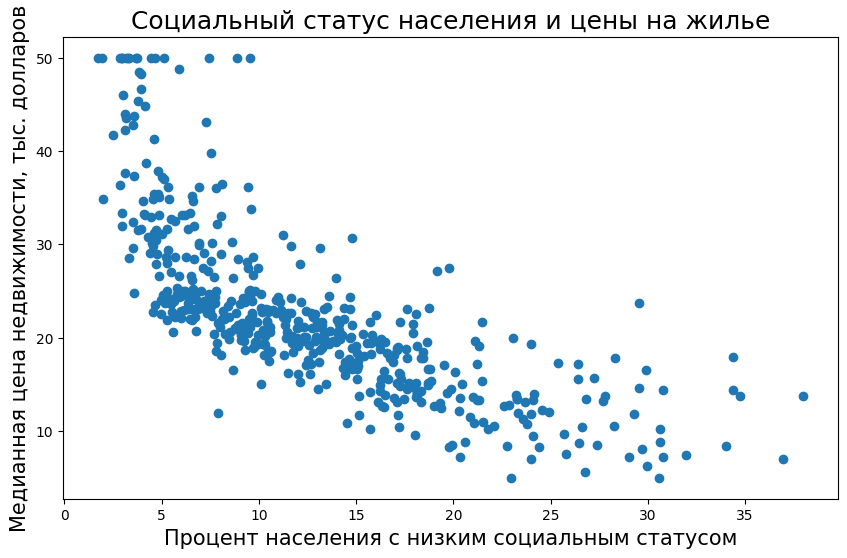

In [10]:
# зададим размер и построим первый график
plt.figure(figsize = (10,6))
plt.scatter(x1, y)
 
# добавим подписи
plt.xlabel('Процент населения с низким социальным статусом', fontsize = 15)
plt.ylabel('Медианная цена недвижимости, тыс. долларов', fontsize = 15)
plt.title('Социальный статус населения и цены на жилье', fontsize = 18)

Text(0.5, 1.0, 'Среднее количество комнат и цены на жилье')

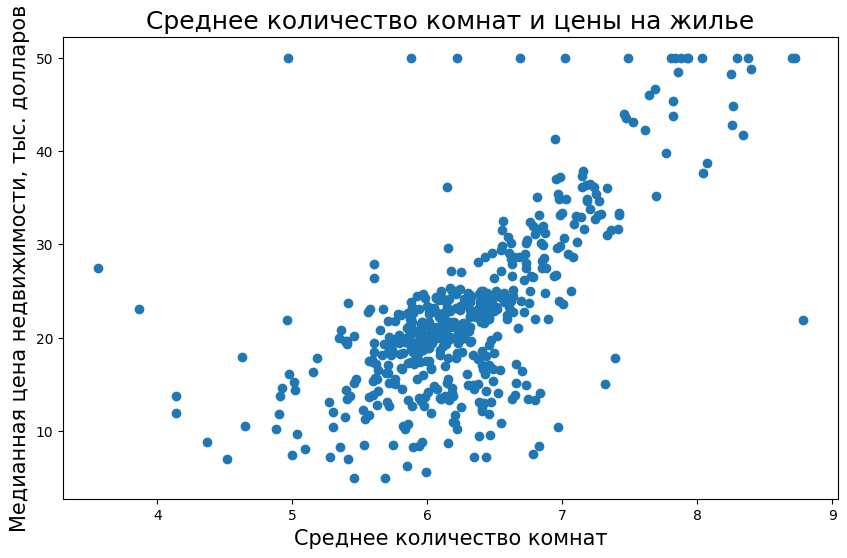

In [11]:
# зададим размер и построим второй график
plt.figure(figsize = (10,6))
plt.scatter(x2, y)
 
# добавим подписи
plt.xlabel('Среднее количество комнат', fontsize = 15)
plt.ylabel('Медианная цена недвижимости, тыс. долларов', fontsize = 15)
plt.title('Среднее количество комнат и цены на жилье', fontsize = 18)

### Этап 4. Отбор и выделение признаков

In [12]:
# отберем признаки с наиболее высокой корреляцией с целевой переменной
# и поместим их в переменную X
X = boston_df[['RM', 'LSTAT', 'PTRATIO', 'TAX', 'INDUS']]

In [13]:
# целевую переменную поместим в переменную y
y = boston_df['MEDV']

In [14]:
print(type(X), type(y))

<class 'pandas.DataFrame'> <class 'pandas.Series'>


In [15]:
from sklearn.model_selection import train_test_split

# разобьем данные на обучающую и тестовую выборку
# размер тестовой выборки составит 30%
# также зададим точку отсчета для воспроизводимости
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = 0.3, 
                                                    random_state = 42)

In [16]:
# посмотрим на новую размерность обучающей
print(X_train.shape, y_train.shape)

# и тестовой выборки
print(X_test.shape, y_test.shape)

(354, 5) (354,)
(152, 5) (152,)


### Этап 5. Обучение и оценка качества модели

In [17]:
# из набора линейных моделей библиотеки sklearn импортируем линейную регрессию
from sklearn.linear_model import LinearRegression
 
# создадим объект этого класса и запишем в переменную model
model = LinearRegression()
 
# обучим нашу модель
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
# на основе нескольких независимых переменных (Х) предскажем цену на жилье (y)
y_pred = model.predict(X_test)
 
# выведем первые пять значений с помощью диапазона индексов
print(y_pred[:5])

[26.62981059 31.10008241 16.95701338 25.59771173 18.09307064]


In [19]:
# импортируем модуль метрик
from sklearn import metrics
 
# выведем корень среднеквадратической ошибки
# сравним тестовые и прогнозные значения цен на жилье
print('Root Mean Squared Error (RMSE):', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))

Root Mean Squared Error (RMSE): 5.107447670220914


In [20]:
# посмотрим на еще одну метрику, R2
print('R2:', np.round(metrics.r2_score(y_test, y_pred), 2))

R2: 0.65


### Дополнительные материалы

Метод .score() класса LinearRegression дает тот же результат, что и метрика r2_score, но для расчета мы передаем ему X_test и y_test.

In [21]:
metrics.r2_score(y_test, y_pred), model.score(X_test, y_test)

(0.6499135956539919, 0.6499135956539919)

Скорректированный коэффициент детерминации

In [22]:
# возьмем n и k для тестовых данных
n, k = X_test.shape[0], X_test.shape[1]
n, k

(152, 5)

In [23]:
# подставим их в формулу
1 - (1 - model.score(X_test, y_test)) * ((n - 1) / (n - k - 1))

0.6379243352311834

### Упражнения

#### Подготовка и исследование данных

**Задание 1**. Вновь загрузите данные по недвижимости в Бостоне.

In [24]:
# Задание 1: повторно загружаем датасет
boston_df = pd.read_csv('boston.csv')
print('Размер:', boston_df.shape)
boston_df.head()

Размер: (506, 14)


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


**Задание 2**. Создайте датафрейм, добавьте целевую переменную и выведите первые семь строк.

In [25]:
# Задание 2: формируем датафрейм и выводим первые 7 строк
# В датасете целевая переменная уже присутствует в столбце MEDV
df = boston_df.copy()
df.head(7)

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2
5,0.02985,0.0,2.18,0.0,0.458,6.430,58.7,6.0622,3.0,222.0,18.7,394.12,5.21,28.7
6,0.08829,12.5,7.87,0.0,0.524,6.012,66.6,5.5605,5.0,311.0,15.2,395.60,12.43,22.9


**Задание 3**. Постройте точечную диаграмму с переменными `PTRATIO` и `MEDV`. Какие выводы можно сделать на основе этого графика?

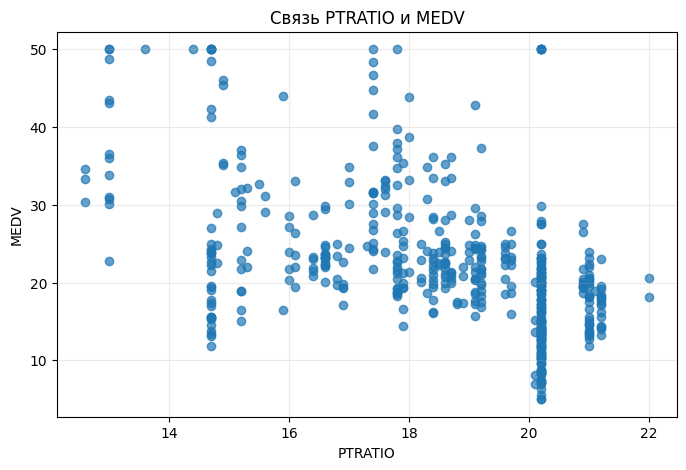

Вывод: заметна отрицательная зависимость — при росте PTRATIO медианная стоимость жилья чаще снижается.


In [26]:
# Задание 3: диаграмма рассеяния PTRATIO vs MEDV
plt.figure(figsize=(8, 5))
plt.scatter(df['PTRATIO'], df['MEDV'], alpha=0.7)
plt.xlabel('PTRATIO')
plt.ylabel('MEDV')
plt.title('Связь PTRATIO и MEDV')
plt.grid(alpha=0.25)
plt.show()

print('Вывод: заметна отрицательная зависимость — при росте PTRATIO медианная стоимость жилья чаще снижается.')

#### Построение и оценка качества модели

**Задание 4**. Возьмите все признаки и поместите их в переменную `X`. Целевую переменную `MEDV` поместите в переменную `y`.

In [27]:
# Задание 4: все признаки в X, целевая переменная в y
X = df.drop(columns='MEDV')
y = df['MEDV']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (506, 13)
y shape: (506,)


**Задание 5**. Разделите выборку на обучающую и тестовую части.

In [28]:
# Задание 5: делим данные на train/test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train:', X_train.shape, y_train.shape)
print('Test :', X_test.shape, y_test.shape)

Train: (404, 13) (404,)
Test : (102, 13) (102,)


**Задание 6**. Постройте модель линейной регрессии (помимо стандартной линейной регрессии, используйте Ridge, Lasso и ElasticNet). Сделайте прогноз и выведите первые три прогнозных значения.

In [29]:
# Задание 6: обучаем LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0, random_state=42),
    'Lasso': Lasso(alpha=0.1, random_state=42, max_iter=10000),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42, max_iter=10000)
}

predictions = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    print(f'{name} первые 3 прогноза: {predictions[name][:3]}')

LinearRegression первые 3 прогноза: [28.99672362 36.02556534 14.81694405]
Ridge первые 3 прогноза: [28.69407967 35.69624973 14.14604677]
Lasso первые 3 прогноза: [28.4034798  33.98676148 13.46016592]
ElasticNet первые 3 прогноза: [28.64006145 34.10355107 13.01259711]


**Задание 7**. Оцените качество модели через RMSE. Сделайте подбор параметров модели для вышения значения метрик.

In [30]:
# Задание 7: считаем RMSE и подбираем лучшие параметры регуляризованных моделей
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

rmse_scores = {
    name: np.sqrt(mean_squared_error(y_test, y_pred))
    for name, y_pred in predictions.items()
}

print('RMSE до подбора параметров:')
for name, score in rmse_scores.items():
    print(f'{name}: {score:.4f}')

tuned_models = {
    'Ridge': (
        Pipeline([
            ('scaler', StandardScaler()),
            ('model', Ridge(random_state=42))
        ]),
        {'model__alpha': [0.01, 0.1, 1, 10, 100]}
    ),
    'Lasso': (
        Pipeline([
            ('scaler', StandardScaler()),
            ('model', Lasso(random_state=42, max_iter=20000))
        ]),
        {'model__alpha': [0.001, 0.01, 0.1, 1, 10]}
    ),
    'ElasticNet': (
        Pipeline([
            ('scaler', StandardScaler()),
            ('model', ElasticNet(random_state=42, max_iter=20000))
        ]),
        {
            'model__alpha': [0.001, 0.01, 0.1, 1],
            'model__l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
        }
    )
}

best_estimators = {}
best_rmse = {}

for name, (pipe, params) in tuned_models.items():
    grid = GridSearchCV(pipe, params, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
    grid.fit(X_train, y_train)

    best_estimators[name] = grid.best_estimator_
    tuned_pred = grid.best_estimator_.predict(X_test)
    best_rmse[name] = np.sqrt(mean_squared_error(y_test, tuned_pred))

    print(f'\n{name} best params: {grid.best_params_}')
    print(f'{name} RMSE после подбора: {best_rmse[name]:.4f}')

RMSE до подбора параметров:
LinearRegression: 4.9286
Ridge: 4.9474
Lasso: 5.0155
ElasticNet: 4.9437

Ridge best params: {'model__alpha': 1}
Ridge RMSE после подбора: 4.9308

Lasso best params: {'model__alpha': 0.001}
Lasso RMSE после подбора: 4.9289

ElasticNet best params: {'model__alpha': 0.01, 'model__l1_ratio': 0.1}
ElasticNet RMSE после подбора: 4.9370


**Задание 8**. Оцените качество модели через R2. Какую долю изменчивости целевой переменной объясняет модель, учитывающая все признаки?

In [31]:
# Задание 8: считаем R2 и интерпретируем долю объясненной изменчивости
from sklearn.metrics import r2_score

r2_scores = {
    name: r2_score(y_test, y_pred)
    for name, y_pred in predictions.items()
}

print('R2 для базовых моделей:')
for name, score in r2_scores.items():
    print(f'{name}: {score:.4f}')

best_linear_name = max(r2_scores, key=r2_scores.get)
print(f'\nЛучшая базовая модель по R2: {best_linear_name} ({r2_scores[best_linear_name]:.4f})')
print(
    f'Это означает, что модель объясняет примерно {r2_scores[best_linear_name] * 100:.1f}% '
    'изменчивости целевой переменной MEDV на тестовой выборке.'
)

# Дополнительно: R2 для моделей после подбора параметров
print('\nR2 после подбора параметров:')
for name, est in best_estimators.items():
    tuned_pred = est.predict(X_test)
    tuned_r2 = r2_score(y_test, tuned_pred)
    print(f'{name}: {tuned_r2:.4f}')

R2 для базовых моделей:
LinearRegression: 0.6688
Ridge: 0.6662
Lasso: 0.6570
ElasticNet: 0.6667

Лучшая базовая модель по R2: LinearRegression (0.6688)
Это означает, что модель объясняет примерно 66.9% изменчивости целевой переменной MEDV на тестовой выборке.

R2 после подбора параметров:
Ridge: 0.6685
Lasso: 0.6687
ElasticNet: 0.6676
